In [1]:
# Standard imports
import polars as pl
import polars.selectors as cs
import seaborn as sns
import plotnine as p9
import numpy as np

# Preprocessing stuff
from sklearn.preprocessing import LabelEncoder, LabelBinarizer, StandardScaler

# Model selection stuff
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV

# Classic classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Multiclass wrappers
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

# Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Metrics

# metric(y_test, y_predict)
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay

In [25]:
import composable.records as rec
from composable.strict import filter

# Lab 3_2 Waterbears

In [5]:
(bears := pl.read_csv("data/WaterBears.csv"))

,Species,SSI,BTWa,BTWs,BTWp,BTWL,BTPA
i64,str,f64,f64,f64,f64,f64,f64
1,"""smokiensis""",28.09,25.2,25.41,25.7,0.61,1.02
2,"""smokiensis""",28.18,23.43,23.94,24.45,0.58,1.04
3,"""smokiensis""",28.82,20.47,21.07,20.85,0.51,1.02
4,"""smokiensis""",29.41,22.69,22.61,22.94,0.55,1.01
5,"""smokiensis""",27.84,22.97,22.84,23.42,0.55,1.02
…,…,…,…,…,…,…,…
37,"""unakaensis""",24.05,22.1,20.79,21.29,0.51,0.96
38,"""unakaensis""",24.42,18.43,18.69,18.12,0.45,0.98
39,"""unakaensis""",25.98,19.78,19.83,19.61,0.49,0.99


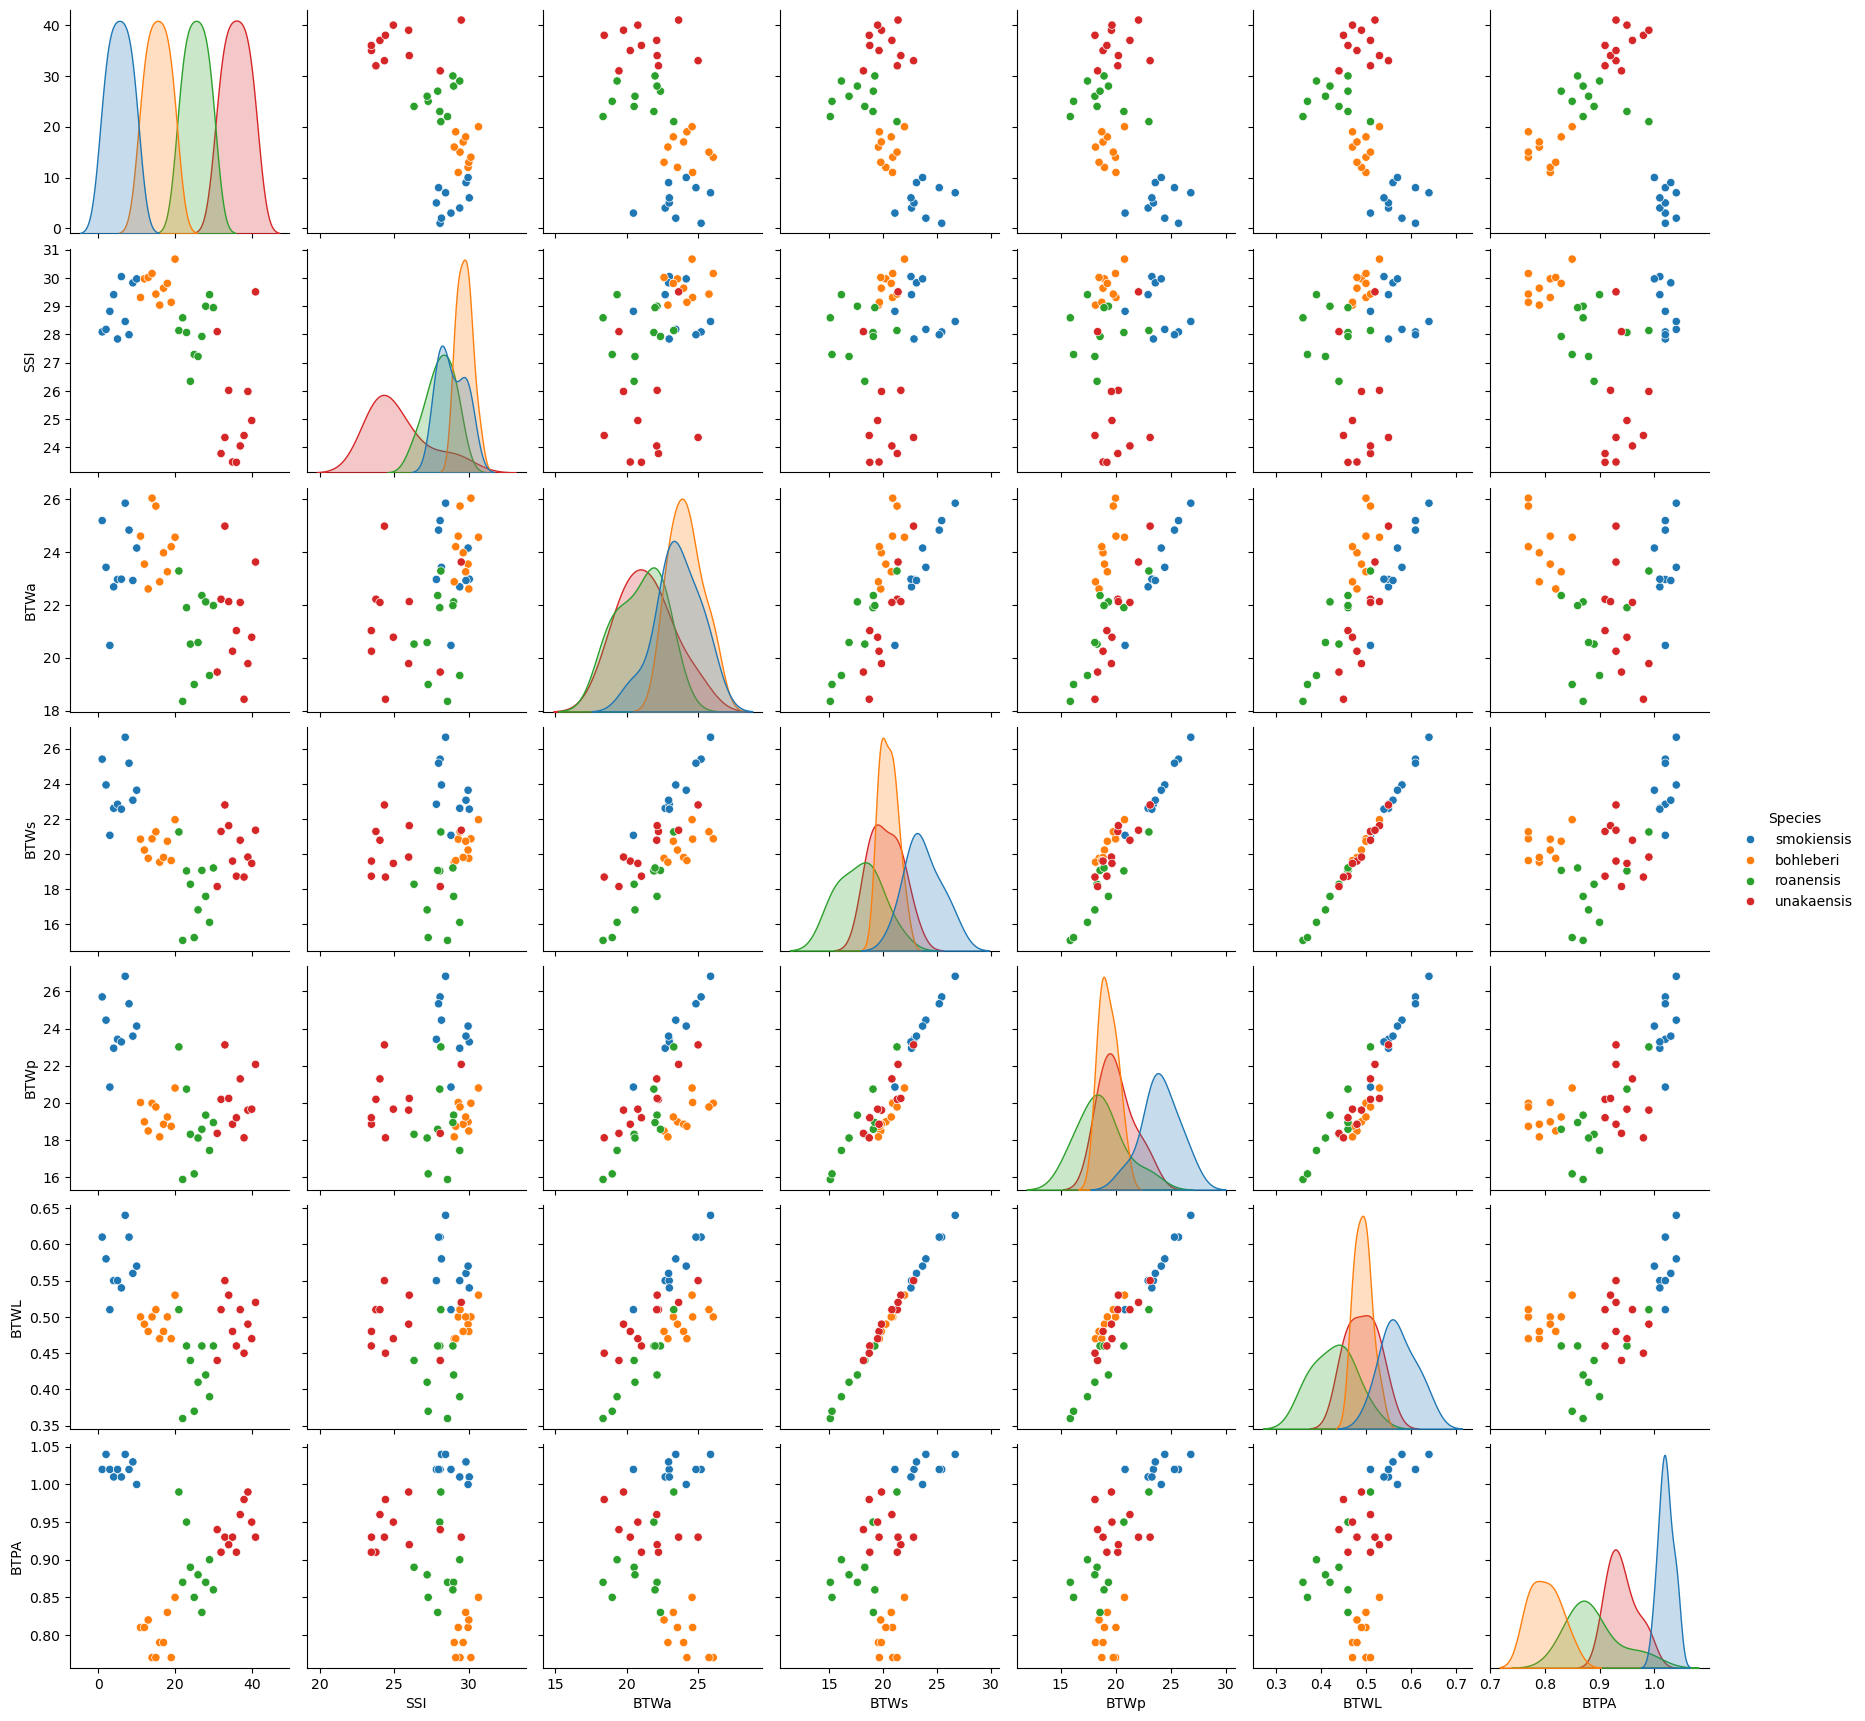

In [9]:
sns.pairplot(
    bears.to_pandas(), 
    hue='Species'
)

In [7]:
(X_bears :=
 bears
 .drop('Species')
 .to_pandas()
).head(2)

,,SSI,BTWa,BTWs,BTWp,BTWL,BTPA
0,1,28.09,25.20,25.41,25.70,0.61,1.02
1,2,28.18,23.43,23.94,24.45,0.58,1.04


In [10]:
(y_bears :=
 bears
 .select('Species')
 .to_numpy()
 .ravel()
)[:3]

array(['smokiensis', 'smokiensis', 'smokiensis'], dtype=object)

# Making the Model

##### 2.	Use a combined grid search to pick a winning model out of the 10 classifiers (5*classic classifiers + 5*OvR).  Note that will be skipping the OneVersusOne classifiers since we want to be able to predict class probabilities.

In [ ]:
(generic_cls :=
 Pipeline(steps = [
     ('scaler', StandardScaler()),
     ('classifier', None)  
 ])

)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


In [12]:
(log_reg_grid :=
 {'classifier': [LogisticRegression(max_iter=10000),
                 OneVsRestClassifier(LogisticRegression(max_iter=10000)),
               ],
 }
)

{'classifier': [LogisticRegression(max_iter=10000),
  OneVsRestClassifier(estimator=LogisticRegression(max_iter=10000))]}

In [13]:
(bayes_grid := 
    {'classifier': [GaussianNB(),
                 OneVsRestClassifier(GaussianNB())
               ],
 })

{'classifier': [GaussianNB(), OneVsRestClassifier(estimator=GaussianNB())]}

In [14]:
(QDA_grid := 
    {'classifier': [QuadraticDiscriminantAnalysis(),
                 OneVsRestClassifier(QuadraticDiscriminantAnalysis())
               ],
 }
)

{'classifier': [QuadraticDiscriminantAnalysis(),
  OneVsRestClassifier(estimator=QuadraticDiscriminantAnalysis())]}

In [15]:
(LDA_grid := 
    {'classifier': [LinearDiscriminantAnalysis(),
                 OneVsRestClassifier(LinearDiscriminantAnalysis())
               ],
 }
)

{'classifier': [LinearDiscriminantAnalysis(),
  OneVsRestClassifier(estimator=LinearDiscriminantAnalysis())]}

In [16]:
std_weights = ['uniform', 'distance']
std_metrics = ['minkowski', 'euclidean', 'manhattan']

In [17]:
(knn_alone := {
    'classifier': [KNeighborsClassifier()],
    'classifier__n_neighbors': list(range(3, 12, 2)),
    'classifier__weights': std_weights,
    'classifier__metric': std_metrics,
    'classifier__p': [1, 2],  
})

{'classifier': [KNeighborsClassifier()],
 'classifier__n_neighbors': [3, 5, 7, 9, 11],
 'classifier__weights': ['uniform', 'distance'],
 'classifier__metric': ['minkowski', 'euclidean', 'manhattan'],
 'classifier__p': [1, 2]}

In [18]:
(wrapped_knn := {
    'classifier': [
        OneVsRestClassifier(KNeighborsClassifier())
    ],
    'classifier__estimator__n_neighbors': list(range(3, 12, 2)),
    'classifier__estimator__weights': std_weights,
    'classifier__estimator__metric': std_metrics,
    'classifier__estimator__p': [1, 2],
})

{'classifier': [OneVsRestClassifier(estimator=KNeighborsClassifier())],
 'classifier__estimator__n_neighbors': [3, 5, 7, 9, 11],
 'classifier__estimator__weights': ['uniform', 'distance'],
 'classifier__estimator__metric': ['minkowski', 'euclidean', 'manhattan'],
 'classifier__estimator__p': [1, 2]}

In [19]:
(knn_full_grid := [knn_alone, wrapped_knn])

[{'classifier': [KNeighborsClassifier()],
  'classifier__n_neighbors': [3, 5, 7, 9, 11],
  'classifier__weights': ['uniform', 'distance'],
  'classifier__metric': ['minkowski', 'euclidean', 'manhattan'],
  'classifier__p': [1, 2]},
 {'classifier': [OneVsRestClassifier(estimator=KNeighborsClassifier())],
  'classifier__estimator__n_neighbors': [3, 5, 7, 9, 11],
  'classifier__estimator__weights': ['uniform', 'distance'],
  'classifier__estimator__metric': ['minkowski', 'euclidean', 'manhattan'],
  'classifier__estimator__p': [1, 2]}]

In [20]:
(combined_grids := [log_reg_grid, bayes_grid, QDA_grid, LDA_grid] + knn_full_grid)

[{'classifier': [LogisticRegression(max_iter=10000),
   OneVsRestClassifier(estimator=LogisticRegression(max_iter=10000))]},
 {'classifier': [GaussianNB(), OneVsRestClassifier(estimator=GaussianNB())]},
 {'classifier': [QuadraticDiscriminantAnalysis(),
   OneVsRestClassifier(estimator=QuadraticDiscriminantAnalysis())]},
 {'classifier': [LinearDiscriminantAnalysis(),
   OneVsRestClassifier(estimator=LinearDiscriminantAnalysis())]},
 {'classifier': [KNeighborsClassifier()],
  'classifier__n_neighbors': [3, 5, 7, 9, 11],
  'classifier__weights': ['uniform', 'distance'],
  'classifier__metric': ['minkowski', 'euclidean', 'manhattan'],
  'classifier__p': [1, 2]},
 {'classifier': [OneVsRestClassifier(estimator=KNeighborsClassifier())],
  'classifier__estimator__n_neighbors': [3, 5, 7, 9, 11],
  'classifier__estimator__weights': ['uniform', 'distance'],
  'classifier__estimator__metric': ['minkowski', 'euclidean', 'manhattan'],
  'classifier__estimator__p': [1, 2]}]

In [31]:
(folds := StratifiedKFold(n_splits=5, shuffle=True, random_state=1204))

StratifiedKFold(n_splits=5, random_state=1204, shuffle=True)

In [32]:
(combined_full_grid_search := GridSearchCV(
    generic_cls,
    combined_grids,
    cv=folds,
    scoring='balanced_accuracy',
    verbose=1
))

,estimator,"Pipeline(step...fier', None)])"
,param_grid,"[{'classifier': [LogisticRegre...ax_iter=10000), OneVsRestClas...x_iter=10000))]}, {'classifier': [GaussianNB(), OneVsRestClas...=GaussianNB())]}, ...]"
,scoring,'balanced_accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [33]:
combined_full_grid_search.fit(X_bears, y_bears)

Fitting 5 folds for each of 128 candidates, totalling 640 fits


c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
c:\Users\kh6102sj\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_p

,estimator,"Pipeline(step...fier', None)])"
,param_grid,"[{'classifier': [LogisticRegre...ax_iter=10000), OneVsRestClas...x_iter=10000))]}, {'classifier': [GaussianNB(), OneVsRestClas...=GaussianNB())]}, ...]"
,scoring,'balanced_accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [ ]:
metrics = ['accuracy',
           'balanced_accuracy',
           'f1_micro',
           ]

(cv_test_scores :=
    cross_validate(combined_full_grid_search, X_bears, y_bears,
               cv=folds,
               scoring=metrics,
               verbose=1,
               n_jobs=-1,
               )
    >> rec.subset([f'test_{m}' for m in metrics])
    >> rec.map(np.mean)
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    7.9s finished


{'test_accuracy': array([0.88888889, 1.        , 1.        , 1.        , 1.        ]),
 'test_balanced_accuracy': array([0.91666667, 1.        , 1.        , 1.        , 1.        ]),
 'test_f1_micro': array([0.88888889, 1.        , 1.        , 1.        , 1.        ])}

## Summary

<font color = "orange">
The combined grid search found that LDA was the best model. It had a strong balanced accuracy score and outperformed QDA, KNN, and all the wrapped multiclass versions. LDA's assumption of shared covariance across classes worked really well for the waterbears dataset, giving it the edge over the more complex QDA and distance-based methods. The CV also had very strong scores of .97 test and most importantly .98 for balanced accuracy meaning it was a very strong model. 
</font>